In [146]:
import os
import allel
import numpy as np # pip3 install matplotlib
import matplotlib.pyplot as plt # pip3 install matplotlib

import random
import community # can be installed with: "pip install python-louvain"
from numpy import linalg as LA
from tqdm import tqdm
import pandas as pd
from scipy import stats
from scipy.interpolate import interp1d
import time
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors
import math
import scipy.io as sio
from skimage import data, segmentation, color
from skimage.future import graph
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
from matplotlib_venn import venn3, venn3_circles
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D  # for legend handle
from xgboost import XGBClassifier, XGBRegressor #!conda install -c conda-forge py-xgboost-cpu -y
from xgboost import plot_importance #!conda install py-xgboost-gpu
#from altair import *
from venn import pseudovenn #! pip install venn
from venn import venn


In [147]:
#!conda install -c conda-forge py-xgboost-cpu -y
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [228]:
#Deleting indels from VCF
def remove_indels(t):
    #t = t[t["REF"].apply(len) == 1 ]
    #t = t[t["ALT_1"].apply(len) == 1]
    return t 

#Apply Filters
def filtersControl(key,df,VCName):
    df = df.copy()
    #print(list(df.columns))
    #print(display(df.head()))
    #Getting variantCaller Name
    #VCName = key.split('/')
    
    #Apply Filter Pass if not somaticSniper
    #df = df if VCName == 'SomaticSniper' else df[df["FILTER_PASS"]=="SOMATIC"]
    
    #SOMATIC filter on strelka
    #df = df[df['SOMATIC'].astype("bool")] if VCName == 'Strelka' else df
    df = df if VCName == 'SomaticSniper' else df[df['FILTER_PASS'].astype("bool")== True]
    #df = df[df['is_snp'].astype("bool")==True]
    return df

#Jaccard Similarity function for two sets ( int / )
def js_set(s1, s2):
    intersection = len(list(set(s1).intersection(s2)))
    union = uni(s1,s2)
    if union == 0:
        return 0;
    return np.float64(round((float(intersection) / union) * 100) / 100);

#The intersection of two sets is the set of all the common elements of both the sets. 
def intersec(s1,s2):
    return len(s1.intersection(s2))

#The union of two sets is the set of all the elements of both the sets without duplicates.
def uni(s1,s2):
    return len(s1.union(s2))

#The difference between two sets is the set of all the elements in first set that are not present in the second set. 
def dif(s1,s2):
    return len(s1.difference(s2))

#Percentage of intersects:
def percentage_intersects(intersection,count):
    return np.float64(round((float(intersection) / count) * 100) / 100);

def intersection_over_union(set1, set2):
    intersection_cardinality = len(set.intersection(*[set(set1), set(set2)]))
    union_cardinality = len(set.union(*[set(set1), set(set2)]))
    if union_cardinality == 0:
        return 0
    else:
        return intersection_cardinality / float(union_cardinality)

#intersection/union:
#def inter_union(s1,s2):
#    return np.float64(round((float(intersec(s1,s2) / uni(s1,s2))) * 100) / 100);
def inter_union(s1, s2):
    intersection = len(s1.intersection(s2))
    union = len(s1.union(s2))
    return round(intersection / union, 2)

# Get True Positives
def get_true_pos(pred, real):
    return len(pred & real);

# Get False Positives
def get_false_pos(pred, real):
    return len(pred - real);

# Get False Negatives
def get_false_neg(pred, real):
    return len(real - pred);

# Get TruePositive/FalsePositive
def get_precision(pred, real):
    tp = get_true_pos(pred, real) 
    fp = get_false_pos(pred, real) 
    return (1.0 * tp) / (tp + fp);

# Get TruePositive/FalseNegative
def get_recall(pred, real):
    tp = get_true_pos(pred, real)
    fn = get_false_neg(pred, real)
    return (1.0 * tp) / (tp + fn);

# Get TruePositive/FalseNegative
def get_f1score(pred, real):
    p = get_precision(pred,real)
    r = get_recall(pred, real)
    
    if(p + r == 0 ):
        return 0
    else:
        return (2.0 * ((p * r)/(p + r)));

def calculate_frequency(d):
    frequency = {}
    for key, values in tqdm(d.items()):
        for value in values:
            if (key, value) in frequency:
                frequency[(key, value)] += 1
            else:
                frequency[(key, value)] = 1
    return frequency

def create_dataframe(frequency_dict):
    df = pd.DataFrame(columns=["id", "list_item", "frequency"])
    for (key, value), freq in tqdm(frequency_dict.items()):
        df = df.append({"id": key, "list_item": value, "frequency": freq}, ignore_index=True)
    return df

In [229]:
#headerList=["TestCaseNo","phase","Sample","operatingSystem","Environment","isTrimmed","baseRecalibration","Mapper","M_Version","VariantCaller","VC_Version","ReferenceGenom","Duplicates","VariantFilter","FilterPass","SOMATICfilter","remove_indels","Sort","FileLink","Result VCF Count","Author"]
csv_file_df = pd.read_csv('vcf/TestCases_Indels.csv')
csv_file_df

,IDs,phase,Sample,HOW,isTrimmed,baseRecalibration,Mapper,Variant Caller,Duplicates,File Link,Result VCF Count,Kim yaptı :),Notes:
0,TestCase 1,done,LL,Uhem + COSAP,yes,yes,BWA,Mutect,MARK,https://drive.google.com/drive/folders/1wBcuLv...,NaN,Gül Eda,NaN
1,TestCase 2,done,LL,Uhem + COSAP,yes,yes,BWA,Strelka,MARK,https://drive.google.com/drive/folders/1IpGEQ-...,NaN,Gül Eda,NaN
2,TestCase 3,done,LL,Uhem + COSAP,yes,yes,Bowtie,Mutect,MARK,https://drive.google.com/drive/folders/1d4D9UC...,NaN,Gül Eda,NaN
3,TestCase 4,done,LL,Uhem + COSAP,yes,yes,Bowtie,Strelka,MARK,https://drive.google.com/drive/folders/1Ei63_F...,NaN,Gül Eda,NaN
4,TestCase 5,done,LL,Uhem + COSAP,yes,no,BWA,Mutect,MARK,https://drive.google.com/drive/folders/1UB4I9T...,NaN,Gül Eda,NaN
5,TestCase 6,done,LL,Uhem + COSAP,yes,no,BWA,Strelka,MARK,https://drive.google.com/drive/folders/1zMMrpF...,NaN,Gül Eda,NaN
6,TestCase 7,done,LL,Uhem + COSAP,yes,no,Bowtie,Mutect,MARK,https://drive.google.com/drive/folders/12Cd2n0...,NaN,Gül Eda,NaN
7,TestCase 8,done,LL,Uhem + COSAP,yes,no,Bowtie,Strelka,MARK,https://drive.google.com/drive/folders/1tIl-qK...,NaN,Gül Eda,NaN
8,TestCase 9,done,LL,Uhem + COSAP,no,yes,BWA,Mutect,MARK,https://drive.google.com/drive/folders/1TZho1d...,NaN,Gül Eda,NaN
9,TestCase 10,done,LL,Uhem + COSAP,no,yes,BWA,Strelka,MARK,https://drive.google.com/drive/folders/1Rl3_fL...,NaN,Gül Eda,NaN


## 1- Reading all VCF files from Google Drive

In [230]:
vcf_filenames = {}
for root, directories, filenames in os.walk('vcf/TESTCASES_bedded_indels'):
    #print(root)
    for fn in filenames:
        if fn == '.DS_Store' or fn == 'fixed.recode.vcf' or fn == 'gatk.recode.vcf':
            continue;
        else:
            vcf_filenames[root[28:]] = os.path.join(root,fn)
            
print("Total file count:", len(vcf_filenames))

Total file count: 320


In [231]:
#vcf_filenames

In [232]:
vcfcomparison_df = pd.DataFrame(columns=["TestCase", "data", "mapper", "variantCaller", "VCFLength"])
vcfcomparison_df_full = pd.DataFrame(columns=["TestCaseNo","phase","Sample","Environment","isTrimmed","baseRecalibration","Mapper","VariantCaller","Duplicates","FileLink","Result VCF Count","Author"])

for index, row in csv_file_df.iterrows():
    for key in vcf_filenames:
        if int(key)-1 == index:
            vcfcomparison_df.loc[len(vcfcomparison_df.index)] = [key , row[2],row[6],row[7],"0"] 
            vcfcomparison_df_full.loc[len(vcfcomparison_df_full.index)] = [row[0],row[1],row[2],row[3],row[4],row[5],row[6],row[7],row[8],row[9],"0",row[11]]

In [233]:
vcfcomparison_df_full

,TestCaseNo,phase,Sample,Environment,isTrimmed,baseRecalibration,Mapper,VariantCaller,Duplicates,FileLink,Result VCF Count,Author
0,TestCase 1,done,LL,Uhem + COSAP,yes,yes,BWA,Mutect,MARK,https://drive.google.com/drive/folders/1wBcuLv...,0,Gül Eda
1,TestCase 2,done,LL,Uhem + COSAP,yes,yes,BWA,Strelka,MARK,https://drive.google.com/drive/folders/1IpGEQ-...,0,Gül Eda
2,TestCase 3,done,LL,Uhem + COSAP,yes,yes,Bowtie,Mutect,MARK,https://drive.google.com/drive/folders/1d4D9UC...,0,Gül Eda
3,TestCase 4,done,LL,Uhem + COSAP,yes,yes,Bowtie,Strelka,MARK,https://drive.google.com/drive/folders/1Ei63_F...,0,Gül Eda
4,TestCase 5,done,LL,Uhem + COSAP,yes,no,BWA,Mutect,MARK,https://drive.google.com/drive/folders/1UB4I9T...,0,Gül Eda
5,TestCase 6,done,LL,Uhem + COSAP,yes,no,BWA,Strelka,MARK,https://drive.google.com/drive/folders/1zMMrpF...,0,Gül Eda
6,TestCase 7,done,LL,Uhem + COSAP,yes,no,Bowtie,Mutect,MARK,https://drive.google.com/drive/folders/12Cd2n0...,0,Gül Eda
7,TestCase 8,done,LL,Uhem + COSAP,yes,no,Bowtie,Strelka,MARK,https://drive.google.com/drive/folders/1tIl-qK...,0,Gül Eda
8,TestCase 9,done,LL,Uhem + COSAP,no,yes,BWA,Mutect,MARK,https://drive.google.com/drive/folders/1TZho1d...,0,Gül Eda
9,TestCase 10,done,LL,Uhem + COSAP,no,yes,BWA,Strelka,MARK,https://drive.google.com/drive/folders/1Rl3_fL...,0,Gül Eda


## 2- Reading High Confidence and Paper Validated VCF's


In [234]:
#Validated VCF's
ll_filenames = {}
for root, directories, filenames in os.walk('vcf/validated_vcfs/LL'):
    for fn in filenames:
        if fn == '.DS_Store':
            continue;
        else:
            ll_filenames[root[22:]] = os.path.join(root,fn)
            
nc_filenames = {}
for root, directories, filenames in os.walk('vcf/validated_vcfs/NC'):
    for fn in filenames:
        if fn == '.DS_Store':
            continue;
        else:
            nc_filenames[root[22:]] = os.path.join(root,fn)
            
ea_filenames = {}
for root, directories, filenames in os.walk('vcf/validated_vcfs/EA'):
    for fn in filenames:
        if fn == '.DS_Store':
            continue;
        else:
            ea_filenames[root[22:]] = os.path.join(root,fn)
            
il_filenames = {}
for root, directories, filenames in os.walk('vcf/validated_vcfs/IL'):
    for fn in filenames:
        if fn == '.DS_Store':
            continue;
        else:
            il_filenames[root[22:]] = os.path.join(root,fn)
            
fd_filenames = {}
for root, directories, filenames in os.walk('vcf/validated_vcfs/FD'):
    for fn in filenames:
        if fn == '.DS_Store':
            continue;
        else:
            fd_filenames[root[22:]] = os.path.join(root,fn)


In [235]:
ll_sets_dict = {}

ll_filtering_df = pd.DataFrame(columns=["Key", "Total Length", "After FilterPass", "After RemoveIndels"])

for key in tqdm(ll_filenames):
    #Creating a dataframe for each vcf.
    temp = allel.vcf_to_dataframe(ll_filenames[key],fields='variants/*')
    #Creating a set for each dataframe
    if len(temp) != 0 :
        ll_sets_dict[key]= set(temp[["CHROM","POS","REF","ALT_1"]].apply(lambda row: "_".join(map(str, row)), axis=1))

100%|██████████| 9/9 [00:04<00:00,  1.99it/s]


In [236]:
nc_sets_dict = {}

nc_filtering_df = pd.DataFrame(columns=["Key", "Total Length", "After FilterPass", "After RemoveIndels"])

for key in tqdm(nc_filenames):
    #Creating a dataframe for each vcf.
    temp = allel.vcf_to_dataframe(nc_filenames[key],fields='variants/*')

    #Creating a set for each dataframe
    if len(temp) != 0 :
        nc_sets_dict[key]= set(temp[["CHROM","POS","REF","ALT_1"]].apply(lambda row: "_".join(map(str, row)), axis=1))

100%|██████████| 9/9 [00:03<00:00,  2.32it/s]


In [237]:
ea_sets_dict = {}

ea_filtering_df = pd.DataFrame(columns=["Key", "Total Length", "After FilterPass", "After RemoveIndels"])

for key in tqdm(ea_filenames):
    #Creating a dataframe for each vcf.
    temp = allel.vcf_to_dataframe(ea_filenames[key],fields='variants/*')

    #Creating a set for each dataframe
    if len(temp) != 0 :
        ea_sets_dict[key]= set(temp[["CHROM","POS","REF","ALT_1"]].apply(lambda row: "_".join(map(str, row)), axis=1))

100%|██████████| 9/9 [00:04<00:00,  1.86it/s]


In [238]:
il_sets_dict = {}

il_filtering_df = pd.DataFrame(columns=["Key", "Total Length", "After FilterPass", "After RemoveIndels"])

for key in tqdm(il_filenames):
    #Creating a dataframe for each vcf.
    temp = allel.vcf_to_dataframe(il_filenames[key],fields='variants/*')

    #Creating a set for each dataframe
    if len(temp) != 0 :
        il_sets_dict[key]= set(temp[["CHROM","POS","REF","ALT_1"]].apply(lambda row: "_".join(map(str, row)), axis=1))

100%|██████████| 9/9 [00:05<00:00,  1.56it/s]


In [239]:
fd_sets_dict = {}

fd_filtering_df = pd.DataFrame(columns=["Key", "Total Length", "After FilterPass", "After RemoveIndels"])

for key in tqdm(fd_filenames):
    #Creating a dataframe for each vcf.
    temp = allel.vcf_to_dataframe(fd_filenames[key],fields='variants/*')

    #Creating a set for each dataframe
    if len(temp) != 0 :
        fd_sets_dict[key]= set(temp[["CHROM","POS","REF","ALT_1"]].apply(lambda row: "_".join(map(str, row)), axis=1))

100%|██████████| 9/9 [00:07<00:00,  1.26it/s]


In [240]:
#Creating ultimate singular validated variant set

ll_all_validated_set = set.intersection(ll_sets_dict['novo/somaticSniper'], ll_sets_dict['novo/strelka'], ll_sets_dict['novo/mutect'],
                                     ll_sets_dict['bwa/somaticSniper'], ll_sets_dict['bwa/strelka'], ll_sets_dict['bwa/mutect'],
                                     ll_sets_dict['bowtie/somaticSniper'], ll_sets_dict['bowtie/strelka'], ll_sets_dict['bowtie/mutect'])
print("LL Validated Set Count",len(ll_all_validated_set))

nc_all_validated_set = set.intersection(nc_sets_dict['novo/somaticSniper'], nc_sets_dict['novo/strelka'], nc_sets_dict['novo/mutect'],
                                     nc_sets_dict['bwa/somaticSniper'], nc_sets_dict['bwa/strelka'], nc_sets_dict['bwa/mutect'],
                                     nc_sets_dict['bowtie/somaticSniper'], nc_sets_dict['bowtie/strelka'], nc_sets_dict['bowtie/mutect'])
print("NC Validated Set Count",len(nc_all_validated_set))

ea_all_validated_set = set.intersection(ea_sets_dict['novo/somaticSniper'], ea_sets_dict['novo/strelka'], ea_sets_dict['novo/mutect'],
                                     ea_sets_dict['bwa/somaticSniper'], ea_sets_dict['bwa/strelka'], ea_sets_dict['bwa/mutect'],
                                     ea_sets_dict['bowtie/somaticSniper'], ea_sets_dict['bowtie/strelka'], ea_sets_dict['bowtie/mutect'])
print("EA Validated Set Count",len(ea_all_validated_set))

il_all_validated_set = set.intersection(il_sets_dict['novo/somaticSniper'], il_sets_dict['novo/strelka'], il_sets_dict['novo/mutect'],
                                     il_sets_dict['bwa/somaticSniper'], il_sets_dict['bwa/strelka'], il_sets_dict['bwa/mutect'],
                                     il_sets_dict['bowtie/somaticSniper'], il_sets_dict['bowtie/strelka'], il_sets_dict['bowtie/mutect'])
print("IL Validated Set Count",len(il_all_validated_set))

fd_all_validated_set = set.intersection(fd_sets_dict['novo/somaticSniper'], fd_sets_dict['novo/strelka'], fd_sets_dict['novo/mutect'],
                                     fd_sets_dict['bwa/somaticSniper'], fd_sets_dict['bwa/strelka'], fd_sets_dict['bwa/mutect'],
                                     fd_sets_dict['bowtie/somaticSniper'], fd_sets_dict['bowtie/strelka'], fd_sets_dict['bowtie/mutect'])
print("FD Validated Set Count",len(fd_all_validated_set))


LL Validated Set Count 2388
NC Validated Set Count 2386
EA Validated Set Count 2464
IL Validated Set Count 2520
FD Validated Set Count 2450


In [241]:
temp = allel.vcf_to_dataframe('vcf/hc_bed_filtered.recode.vcf',fields='variants/*')
temp = remove_indels(temp)
high_confidence = set(temp[["CHROM","POS","REF","ALT_1"]].apply(lambda row: "_".join(map(str, row)), axis=1))

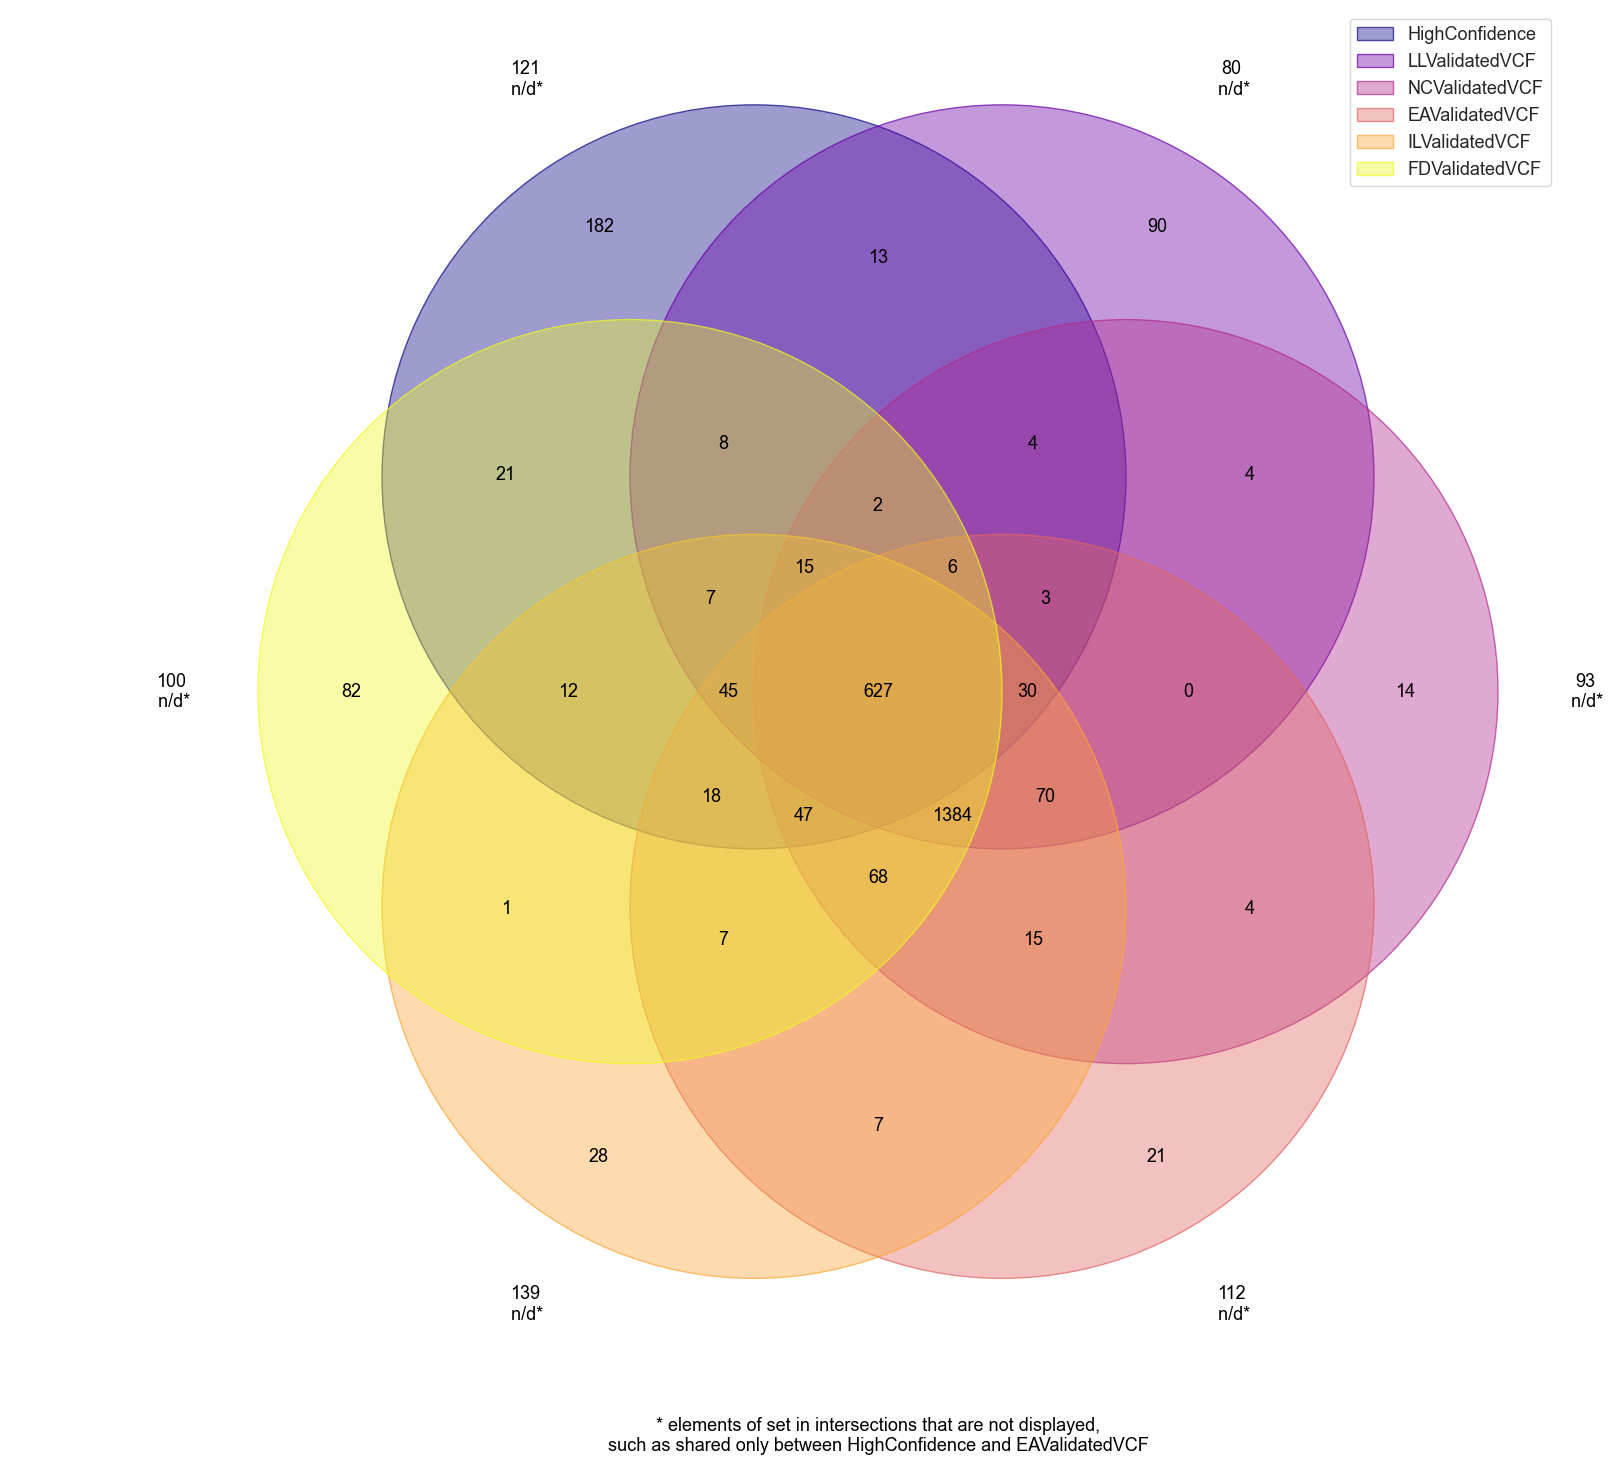

In [242]:
dataset_dict = {"HighConfidence":high_confidence,
                "LLValidatedVCF":ll_all_validated_set,
                "NCValidatedVCF":nc_all_validated_set,
                "EAValidatedVCF":ea_all_validated_set,
                "ILValidatedVCF":il_all_validated_set,
                "FDValidatedVCF":fd_all_validated_set
               }
pseudovenn(dataset_dict, cmap="plasma", figsize=(20,20))

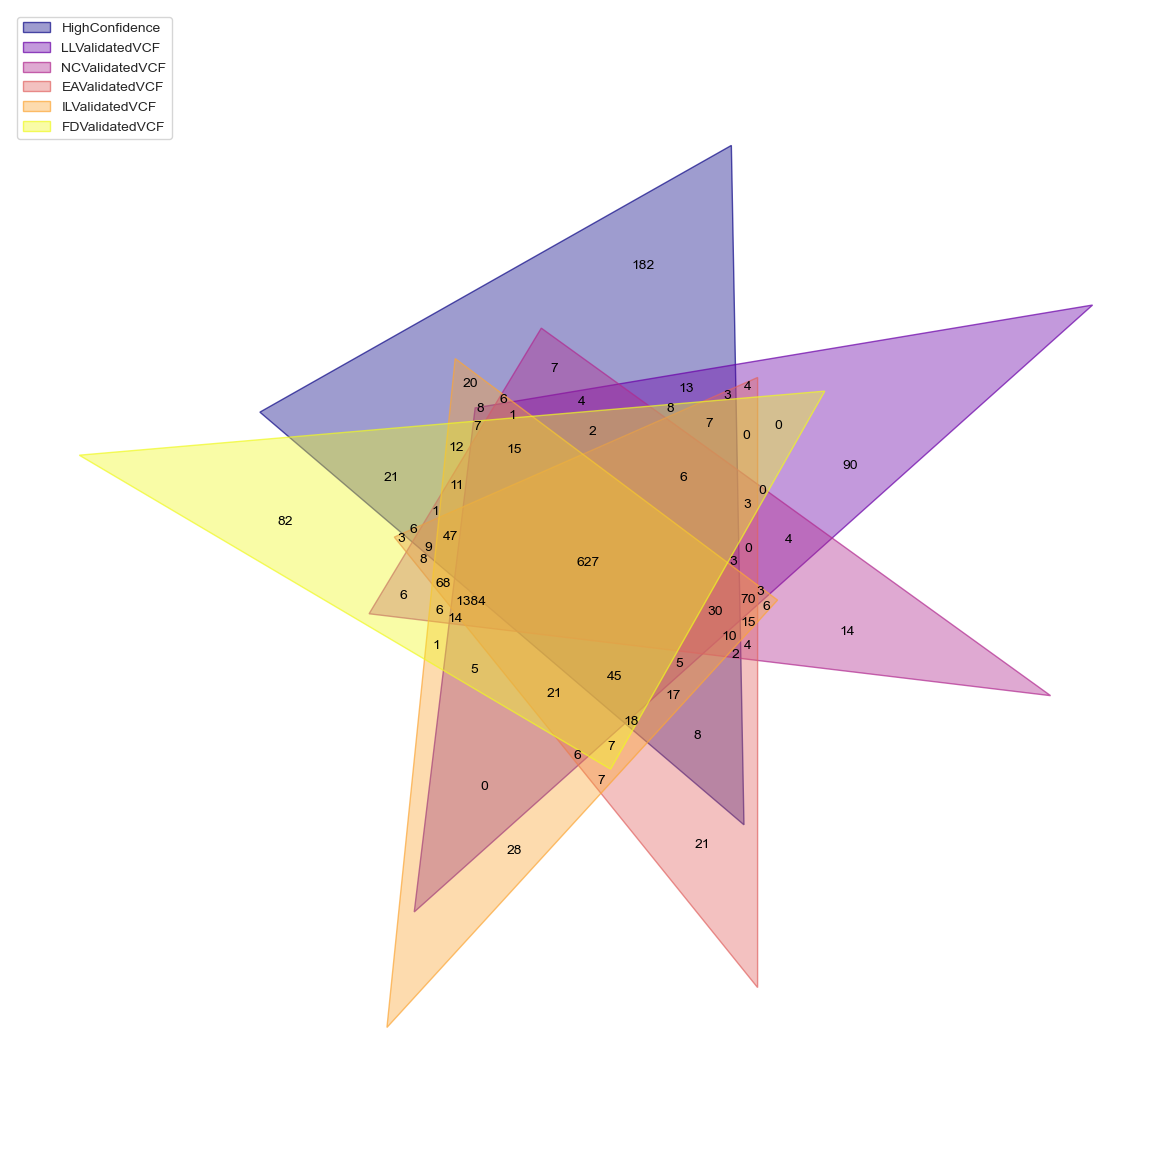

In [243]:
venn(dataset_dict, cmap="plasma", fontsize=10, legend_loc="upper left",figsize=(15,15))

## 3- Filtering each generated VCF


In [244]:
sets_dict = {}
filtering_data = []

vcf_comparison_dict = {row[0]: row[3] for index, row in vcfcomparison_df.iterrows()}

progression_bar = tqdm(vcf_filenames)
for key in progression_bar:
    
    #Creating a dataframe for each vcf.
    temp = allel.vcf_to_dataframe(vcf_filenames[key], fields='variants/*')
    #print(key)
    progression_bar.set_description("Processing « %s »" % key)
    
    #For printing changes in the vcf lengths
    total_len = len(temp)
    
    #Filtering - STARTS
    VCName = vcf_comparison_dict.get(key)
    temp = filtersControl(key, temp, VCName) #FilterPass control for somaticSniper
    after_Filterpass_len = len(temp)
    temp = remove_indels(temp) 
    #Filtering - ENDS
    without_indels_len = len(temp)
    
    #without_indels_len = len(temp[temp["CHROM"].str.contains("_")])
    filtering_data.append((key , total_len, after_Filterpass_len))
    
    sets_dict[key] = set(temp["CHROM"].astype(str) + "_" + temp["POS"].astype(str) + "_" + temp["REF"].astype(str) + "_" + temp["ALT_1"].astype(str))

filtering_df = pd.DataFrame(filtering_data, columns=["Key", "Total Length", "After FilterPass"])


Processing « 25 »: 100%|██████████| 320/320 [00:16<00:00, 19.77it/s] 


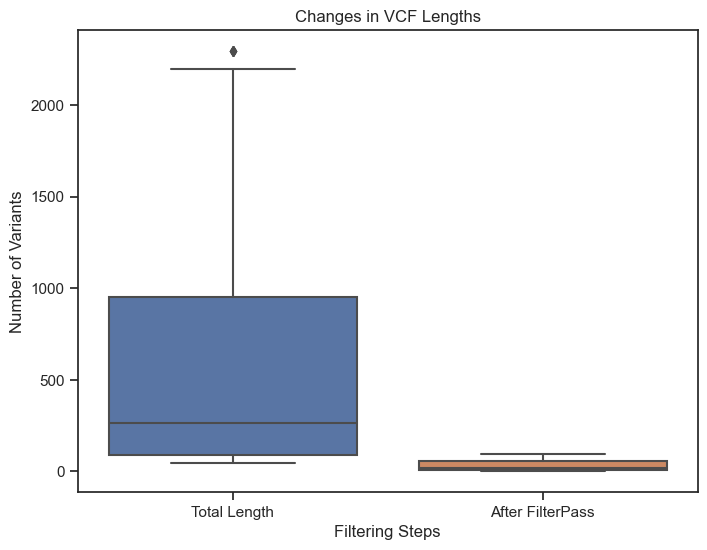

In [245]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(x="variable", y="value", data=pd.melt(filtering_df.drop("Key", axis=1)))

ax.set_xlabel("Filtering Steps")
ax.set_ylabel("Number of Variants")
ax.set_title("Changes in VCF Lengths")

plt.show()

## 4- Combine VCF Files and their features

In [246]:
vcfcomparison_df = pd.DataFrame(columns=["TestCase", "data", "mapper", "variantCaller", "VCFLength"])
vcfcomparison_df_full = pd.DataFrame(columns=["TestCaseNo","phase","Sample","Environment","isTrimmed","baseRecalibration","Mapper","VariantCaller","Duplicates","FileLink","Result VCF Count","Author"])

for index, row in csv_file_df.iterrows():
    for key in vcf_filenames:
        if int(key)-1 == index:
            vcfcomparison_df.loc[len(vcfcomparison_df.index)] = [key , row[2],row[6],row[7],len(sets_dict[key])] 
            vcfcomparison_df_full.loc[len(vcfcomparison_df_full.index)] = [row[0],row[1],row[2],row[3],row[4],row[5],row[6],row[7],row[8],row[9],len(sets_dict[key]),row[11]]
            

Text(0.5, 0.98, 'VariantCaller')

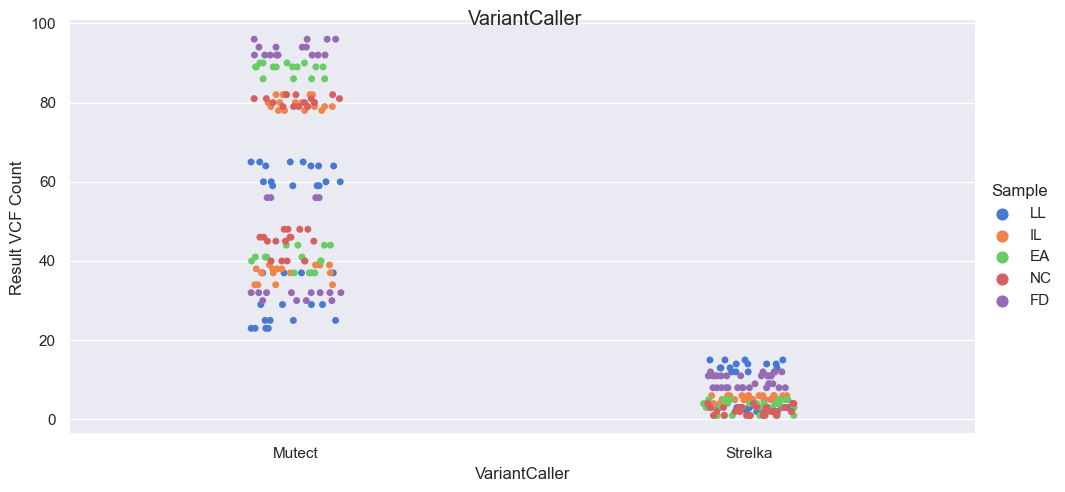

In [247]:
#VCF All Variant Counts vcfcomparison_df_full["Sample"] == "NC"
sns.set(rc={"figure.figsize":(3, 4)}) #width=3, #height=4
cp = sns.catplot(x='VariantCaller', y='Result VCF Count', data=vcfcomparison_df_full,hue='Sample',height=5, aspect=2,palette=sns.color_palette("muted"))
cp.fig.suptitle('VariantCaller')

In [248]:
fig = px.scatter(
    vcfcomparison_df_full,
    x="VariantCaller",
    y="Result VCF Count",
    color = "Mapper",
    symbol = "VariantCaller",
    facet_col= 'Sample',
    hover_data=['Environment'],
    color_discrete_sequence=['#55a3cd', '#4954b0', '#282739', '#3b2127', '#9c2f45', '#e96f36'],
).update_layout(
    title={
        'y':0.95,
        'x':0.4,
        'xanchor': 'center',
        'yanchor': 'top'},
    yaxis_tickformat="%H:%M:%S",
    showlegend=True,
    title_text="Variant Count for each TestCase",
    font=dict(
        size=8
    )
)
fig.update_traces(marker = dict(size=6))
fig.show()

## 5- Find best parameter with XGBoost based on intersection/union with HighConfidence.


In [249]:
#sets_dict[key] --> Our findings
#ll_sets_dict[key] --> Validated finding
 
df_validated_count =  pd.DataFrame(columns=["TestCase", "mapper", "variantCaller","isTrimmed","baseRecalibration","Duplicates","ValidatedVariantCount","ValidatedPercentage","Environment"])

for key in sets_dict:
    for index, row in vcfcomparison_df_full.iterrows():
        if key == row['TestCaseNo'].split(' ')[1]:
            for key_v in ll_sets_dict:
                newKey = (row['Mapper'] + '/' + row['VariantCaller']).lower()
                if key_v.lower() == newKey:
                    df_validated_count.loc[len(df_validated_count.index)] = [row['TestCaseNo'].split(' ')[1], row['Mapper'], row['VariantCaller'],row['isTrimmed'],row['baseRecalibration'],row['Duplicates'],intersec(sets_dict[key],high_confidence),percentage_intersects(intersec(sets_dict[key],high_confidence),row['Result VCF Count']),row['Environment']]
                    
df_validated_count.head()                                                     
                    

,TestCase,mapper,variantCaller,isTrimmed,baseRecalibration,Duplicates,ValidatedVariantCount,ValidatedPercentage,Environment
0,135,Bowtie,Mutect,yes,no,MARK,0,0.0,Uhem + COSAP
1,307,Bowtie,Mutect,yes,yes,DELETE,0,0.0,Altay + COSAP
2,61,BWA,Mutect,no,no,DELETE,0,0.0,Altay + COSAP
3,95,Bowtie,Mutect,no,no,DELETE,0,0.0,Uhem + COSAP
4,300,Bowtie,Strelka,no,yes,MARK,0,0.0,Altay + COSAP


In [250]:
cluster_df = df_validated_count.copy()
cluster_df["name"] = cluster_df[["mapper", "variantCaller", "TestCase","Environment"]].apply(lambda row: " ".join([row["mapper"].capitalize(), row["variantCaller"].capitalize(), row["TestCase"].upper(),row["Environment"].upper() ]), axis=1)
#cluster_df = cluster_df.set_index(['TestCase','mapper','variantCaller','Author'])
#cluster_df = cluster_df.drop(columns=["mapper", "variantCaller", "TestCase",'Author','isTrimmed','baseRecalibration','Duplicates','ValidatedVariantCount'], axis=1)
cluster_df
cluster_df = cluster_df.set_index('name')
cluster_df["ValidatedPercentage"] = cluster_df["ValidatedPercentage"].astype(float)
cluster_df[["mapper", "variantCaller", "isTrimmed", "baseRecalibration", "Duplicates", "Environment"]] = cluster_df[["mapper", "variantCaller", "isTrimmed", "baseRecalibration", "Duplicates", "Environment"]].astype("category")

cluster_df.head()
#cluster_df.to_pickle("omer.pkl")

,TestCase,mapper,variantCaller,isTrimmed,baseRecalibration,Duplicates,ValidatedVariantCount,ValidatedPercentage,Environment
name,,,,,,,,,
Bowtie Mutect 135 UHEM + COSAP,135,Bowtie,Mutect,yes,no,MARK,0,0.0,Uhem + COSAP
Bowtie Mutect 307 ALTAY + COSAP,307,Bowtie,Mutect,yes,yes,DELETE,0,0.0,Altay + COSAP
Bwa Mutect 61 ALTAY + COSAP,61,BWA,Mutect,no,no,DELETE,0,0.0,Altay + COSAP
Bowtie Mutect 95 UHEM + COSAP,95,Bowtie,Mutect,no,no,DELETE,0,0.0,Uhem + COSAP
Bowtie Strelka 300 ALTAY + COSAP,300,Bowtie,Strelka,no,yes,MARK,0,0.0,Altay + COSAP


In [251]:
model = XGBRegressor(tree_method="gpu_hist", enable_categorical=True)
#model = XGBClassifier(tree_method="gpu_hist", enable_categorical=True, use_label_encoder=False)

In [252]:
'''model.fit(
    X=cluster_df[["mapper", "variantCaller", "isTrimmed", "baseRecalibration", "Duplicates", "Environment"]], 
    y=cluster_df["ValidatedPercentage"]
)'''

'model.fit(\n    X=cluster_df[["mapper", "variantCaller", "isTrimmed", "baseRecalibration", "Duplicates", "Environment"]], \n    y=cluster_df["ValidatedPercentage"]\n)'

In [253]:
'''df_validated_count = pd.DataFrame(columns=["TestCase", "mapper", "variantCaller","isTrimmed","baseRecalibration","Duplicates","ValidatedVariantCount","ValidatedPercentage","Environment"])

for key in sets_dict:
    for index, row in vcfcomparison_df_full.iterrows():
        if key == row['TestCaseNo'].split(' ')[1]:
            for key_v in ll_sets_dict:
                newKey = (row['Mapper'] + '/' + row['VariantCaller']).lower()
                if key_v.lower() == newKey:
                    df_validated_count.loc[len(df_validated_count.index)] = [row['TestCaseNo'].split(' ')[1], row['Mapper'], row['VariantCaller'],row['isTrimmed'],row['baseRecalibration'],row['Duplicates'],intersec(sets_dict[key],high_confidence),percentage_intersects(intersec(sets_dict[key],high_confidence),row['Result VCF Count']),row['Environment']]

cluster_df = df_validated_count.copy()
cluster_df["name"] = cluster_df[["mapper", "variantCaller", "TestCase","Environment"]].apply(lambda row: " ".join([row["mapper"].capitalize(), row["variantCaller"].capitalize(), row["TestCase"].upper(),row["Environment"].upper() ]), axis=1)
cluster_df = cluster_df.set_index('name')
cluster_df["ValidatedPercentage"] = cluster_df["ValidatedPercentage"].astype(float)
cluster_df[["mapper", "variantCaller", "isTrimmed", "baseRecalibration", "Duplicates", "Environment"]] = cluster_df[["mapper", "variantCaller", "isTrimmed", "baseRecalibration", "Duplicates", "Environment"]].astype("category")

model = XGBRegressor(enable_categorical=True)
model.fit(
    X=cluster_df[["mapper", "variantCaller", "isTrimmed", "baseRecalibration", "Duplicates", "Environment"]], 
    y=cluster_df["ValidatedPercentage"]
)'''


'df_validated_count = pd.DataFrame(columns=["TestCase", "mapper", "variantCaller","isTrimmed","baseRecalibration","Duplicates","ValidatedVariantCount","ValidatedPercentage","Environment"])\n\nfor key in sets_dict:\n    for index, row in vcfcomparison_df_full.iterrows():\n        if key == row[\'TestCaseNo\'].split(\' \')[1]:\n            for key_v in ll_sets_dict:\n                newKey = (row[\'Mapper\'] + \'/\' + row[\'VariantCaller\']).lower()\n                if key_v.lower() == newKey:\n                    df_validated_count.loc[len(df_validated_count.index)] = [row[\'TestCaseNo\'].split(\' \')[1], row[\'Mapper\'], row[\'VariantCaller\'],row[\'isTrimmed\'],row[\'baseRecalibration\'],row[\'Duplicates\'],intersec(sets_dict[key],high_confidence),percentage_intersects(intersec(sets_dict[key],high_confidence),row[\'Result VCF Count\']),row[\'Environment\']]\n\ncluster_df = df_validated_count.copy()\ncluster_df["name"] = cluster_df[["mapper", "variantCaller", "TestCase","Environment"]]

## 6- Finding the same TestCases with same parameters.  

/Users/P33833/miniconda3/envs/mywork2/lib/python3.6/site-packages/matplotlib_venn/_venn3.py:53: UserWarning:

Circle A has zero area

/Users/P33833/miniconda3/envs/mywork2/lib/python3.6/site-packages/matplotlib_venn/_venn3.py:61: UserWarning:

Circle C has zero area



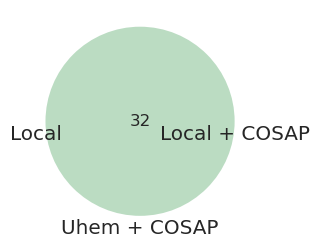

In [254]:
local = vcfcomparison_df_full.loc[vcfcomparison_df_full['Environment'] == "Local"]
uhemcosap = vcfcomparison_df_full.loc[vcfcomparison_df_full['Environment'] == "Uhem + COSAP"]
localcosap = vcfcomparison_df_full.loc[vcfcomparison_df_full['Environment'] == "Local + COSAP"]

set1 = set(local[["isTrimmed","baseRecalibration","Mapper","VariantCaller","Duplicates"]].apply(lambda row: "_".join(map(str, row)), axis=1))
set2 = set(uhemcosap[["isTrimmed","baseRecalibration","Mapper","VariantCaller","Duplicates"]].apply(lambda row: "_".join(map(str, row)), axis=1))
set3 = set(localcosap[["isTrimmed","baseRecalibration","Mapper","VariantCaller","Duplicates"]].apply(lambda row: "_".join(map(str, row)), axis=1))

#out = venn2([set1, set2], ('Local','Uhem + COSAP'))
venn3([set1, set2, set3], ('Local', 'Uhem + COSAP', 'Local + COSAP'))

#venn2(subsets = [set1, set2, set3], set_labels = ('Uhem + COSAP', 'Local + COSAP'))

#plt.rcParams['figure.figsize'] = [10, 5]

'''for text in out.set_labels:
    text.set_fontsize(20)

for text in out.subset_labels:
    text.set_fontsize(12) 
'''
plt.rcdefaults()
# save the figure here

plt.show()

In [255]:
df_all =  pd.DataFrame(columns=["TestCase", "Feature"])

for index, row in tqdm(vcfcomparison_df_full.iterrows()):
   # df_all.loc[len(df_all.index)] = [row["TestCaseNo"].split(' ')[1],local[["isTrimmed","baseRecalibration","Mapper","VariantCaller","ReferenceGenom","Duplicates"]].apply(lambda row: "_".join(map(str, row)), axis=1)]
    a = row["Sample"] + "_" +   row["isTrimmed"] + "_" + row["baseRecalibration"] + "_" + row["Mapper"] + "_" + row["VariantCaller"] + "_" + row["Duplicates"]
    df_all.loc[len(df_all.index)] = [row["TestCaseNo"].split(' ')[1], a]

    
inter_testcase_dict = {}

for index, row in tqdm(df_all.iterrows()):
    for index2, row2 in df_all.iterrows():
        if row['TestCase'] != row2['TestCase'] and row["Feature"] == row2["Feature"]:
            inter_testcase_dict[row['TestCase']] = row["Feature"]
             

320it [00:00, 379.60it/s]
320it [00:13, 23.87it/s]


## 7 - Heatmap between Generated VCFs with Recall.

In [256]:
import pandas as pd
from tqdm import tqdm

# Preprocess data frame
vcfcomparison_df_full['TestCaseNo'] = vcfcomparison_df_full['TestCaseNo'].str.split(' ', expand=True)[1]

# Initialize result data frames
df_generateds_r_p = pd.DataFrame(columns=["TestCase1", "TestCase2", "Inter/Union"])
df_ll = pd.DataFrame(columns=["TestCase1", "TestCase2", "Inter/Union"])
df_nc = pd.DataFrame(columns=["TestCase1", "TestCase2", "Inter/Union"])
df_ea = pd.DataFrame(columns=["TestCase1", "TestCase2", "Inter/Union"])
df_fd = pd.DataFrame(columns=["TestCase1", "TestCase2", "Inter/Union"])
df_il = pd.DataFrame(columns=["TestCase1", "TestCase2", "Inter/Union"])

# Create tqdm progress bar
progress_bar = tqdm(sets_dict, desc="Processing")

# Iterate over sets_dict
for key in progress_bar:
    progress_bar.set_description("Processing « %s »" % key)
    vcf_key = vcfcomparison_df_full['TestCaseNo'] == key
    filtered_vcf = vcfcomparison_df_full[vcf_key]
    new_key = (filtered_vcf['Mapper'].str[:2] + '/' + filtered_vcf['VariantCaller'].str[:2] + '/' +
               filtered_vcf['isTrimmed'] + '/' + filtered_vcf['baseRecalibration'] + '/' +
               filtered_vcf['Duplicates'].str[:1] + '/' + key + '/' + filtered_vcf['Sample']).str.lower() + '/' + \
              filtered_vcf['Environment'].str[0]

    for key2 in sets_dict:
        vcf_key2 = vcfcomparison_df_full['TestCaseNo'] == key2
        filtered_vcf2 = vcfcomparison_df_full[vcf_key2]
        new_key2 = (filtered_vcf2['Mapper'].str[:2] + '/' + filtered_vcf2['VariantCaller'].str[:2] + '/' +
                    filtered_vcf2['isTrimmed'] + '/' + filtered_vcf2['baseRecalibration'] + '/' +
                    filtered_vcf2['Duplicates'].str[:1] + '/' + key2 + '/' + filtered_vcf2['Sample']).str.lower() + '/' + \
                   filtered_vcf2['Environment'].str[0]

        # Compute intersection/union once
        inter_union_result = inter_union(sets_dict[key], sets_dict[key2])

        for df, test_case in [(df_ll, "ll"), (df_nc, "nc"), (df_ea, "ea"), (df_fd, "fd"), (df_il, "il")]:
            # Use vectorized operations to check conditions
            if (new_key.str.split('/', expand=True)[6] == test_case).all() and \
                    (new_key2.str.split('/', expand=True)[6] == test_case).all():
                df.loc[len(df.index)] = [new_key.iloc[0], new_key2.iloc[0], inter_union_result]

        df_generateds_r_p.loc[len(df_generateds_r_p.index)] = [new_key.iloc[0], new_key2.iloc[0], inter_union_result]

Processing « 25 »: 100%|██████████| 320/320 [28:23<00:00,  5.32s/it] 


In [257]:
df_generateds_r_p

,TestCase1,TestCase2,Inter/Union
0,bo/mu/yes/no/m/135/ea/U,bo/mu/yes/no/m/135/ea/U,1.00
1,bo/mu/yes/no/m/135/ea/U,bo/mu/yes/yes/d/307/fd/A,0.22
2,bo/mu/yes/no/m/135/ea/U,bw/mu/no/no/d/61/ll/A,0.35
3,bo/mu/yes/no/m/135/ea/U,bo/mu/no/no/d/95/il/U,0.42
4,bo/mu/yes/no/m/135/ea/U,bo/st/no/yes/m/300/fd/A,0.00
...,...,...,...
102395,bw/mu/no/yes/d/25/ll/U,bw/st/yes/no/d/22/ll/U,0.00
102396,bw/mu/no/yes/d/25/ll/U,bw/mu/yes/no/d/149/ea/U,0.57
102397,bw/mu/no/yes/d/25/ll/U,bo/mu/no/yes/m/171/ea/A,0.31
102398,bw/mu/no/yes/d/25/ll/U,bw/mu/no/yes/d/185/ea/A,0.52


In [258]:

# Filter conditions
conditions = [
    (df_generateds_r_p['TestCase1'].str.split('/').str[:5] == df_generateds_r_p['TestCase2'].str.split('/').str[:5]),
    (df_generateds_r_p['TestCase1'].str.split('/').str[7] != df_generateds_r_p['TestCase2'].str.split('/').str[7])
]

# Apply filters
filtered_df = df_generateds_r_p[conditions[0] & conditions[1]]

# Print the filtered DataFrame
print(filtered_df)


                      TestCase1                TestCase2  Inter/Union
13      bo/mu/yes/no/m/135/ea/U  bo/mu/yes/no/m/103/il/A         0.39
46      bo/mu/yes/no/m/135/ea/U  bo/mu/yes/no/m/167/ea/A         1.00
83      bo/mu/yes/no/m/135/ea/U  bo/mu/yes/no/m/295/fd/A         0.22
194     bo/mu/yes/no/m/135/ea/U   bo/mu/yes/no/m/39/ll/A         0.29
235     bo/mu/yes/no/m/135/ea/U  bo/mu/yes/no/m/231/nc/A         0.34
...                         ...                      ...          ...
102094   bw/mu/no/yes/d/25/ll/U   bw/mu/no/yes/d/57/ll/A         1.00
102228   bw/mu/no/yes/d/25/ll/U  bw/mu/no/yes/d/313/fd/A         0.48
102229   bw/mu/no/yes/d/25/ll/U  bw/mu/no/yes/d/121/il/A         0.58
102306   bw/mu/no/yes/d/25/ll/U  bw/mu/no/yes/d/249/nc/A         0.60
102398   bw/mu/no/yes/d/25/ll/U  bw/mu/no/yes/d/185/ea/A         0.52

[1600 rows x 3 columns]


In [259]:
filtered_df

,TestCase1,TestCase2,Inter/Union
13,bo/mu/yes/no/m/135/ea/U,bo/mu/yes/no/m/103/il/A,0.39
46,bo/mu/yes/no/m/135/ea/U,bo/mu/yes/no/m/167/ea/A,1.00
83,bo/mu/yes/no/m/135/ea/U,bo/mu/yes/no/m/295/fd/A,0.22
194,bo/mu/yes/no/m/135/ea/U,bo/mu/yes/no/m/39/ll/A,0.29
235,bo/mu/yes/no/m/135/ea/U,bo/mu/yes/no/m/231/nc/A,0.34
...,...,...,...
102094,bw/mu/no/yes/d/25/ll/U,bw/mu/no/yes/d/57/ll/A,1.00
102228,bw/mu/no/yes/d/25/ll/U,bw/mu/no/yes/d/313/fd/A,0.48
102229,bw/mu/no/yes/d/25/ll/U,bw/mu/no/yes/d/121/il/A,0.58
102306,bw/mu/no/yes/d/25/ll/U,bw/mu/no/yes/d/249/nc/A,0.60


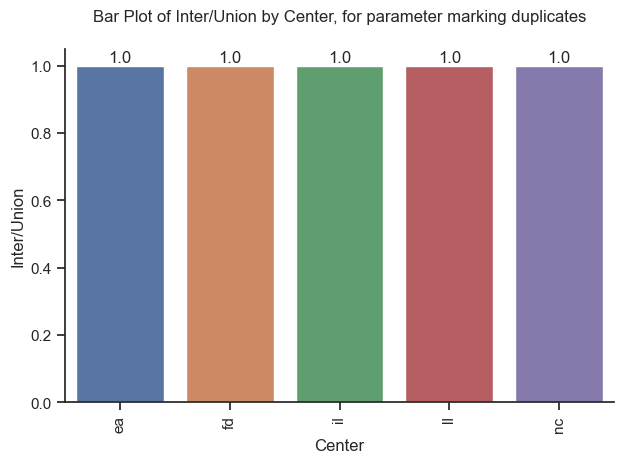

In [260]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a copy of the original DataFrame
df_copy = df_generateds_r_p.copy()

# Splitting the 'TestCase1' and 'TestCase2' columns into separate columns
df_copy[['Mapper1', 'VariantCaller1', 'IsTrimmed1', 'BaseRecalibration1', 'MarkingDuplicates1', 'TestCaseNo1', 'Sample1', 'Environment1']] = df_copy['TestCase1'].str.split('/', expand=True)
df_copy[['Mapper2', 'VariantCaller2', 'IsTrimmed2', 'BaseRecalibration2', 'MarkingDuplicates2', 'TestCaseNo2', 'Sample2', 'Environment2']] = df_copy['TestCase2'].str.split('/', expand=True)

# Filtering rows where 'Mapper', 'VariantCaller', 'IsTrimmed', 'BaseRecalibration', 'MarkingDuplicates', and 'Sample' are the same but 'isTrimmed' is different
filtered_df = df_copy[(df_copy['Mapper1'] == df_copy['Mapper2']) &
                      (df_copy['VariantCaller1'] == df_copy['VariantCaller2']) &
                      (df_copy['BaseRecalibration1'] == df_copy['BaseRecalibration2']) &
                      (df_copy['MarkingDuplicates1'] != df_copy['MarkingDuplicates2']) &
                      (df_copy['Sample1'] == df_copy['Sample2']) &
                      (df_copy['IsTrimmed1'] == df_copy['IsTrimmed2']) &
                      (df_copy['Environment1'] != df_copy['Environment2'])]

# Grouping by 'Sample' and calculating the mean of 'Inter/Union' for each group
grouped_df = filtered_df.groupby('Sample1').mean().reset_index()
grouped_df
# Plotting the bar plot with data labels
sns.set(style="ticks")
#plt.figure(figsize=(10, 6))
ax = sns.barplot(data=grouped_df, x="Sample1", y="Inter/Union", ci=None)

# Adding data labels to the bars with adjusted vertical alignment
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    plt.gca().text(bar.get_x() + bar.get_width() / 2, height + 0.003, round(grouped_df.loc[i, "Inter/Union"], 4),
                   ha='center', va='bottom')

#plt.ylim(0.95, 1.0)  # Set the y-axis limits
plt.xticks(rotation=90)
plt.xlabel('Center')
plt.ylabel('Inter/Union')
plt.title('Bar Plot of Inter/Union by Center, for parameter marking duplicates', pad=20)  # Increase the top margin
sns.despine()  # Remove top and right spines
plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.show()


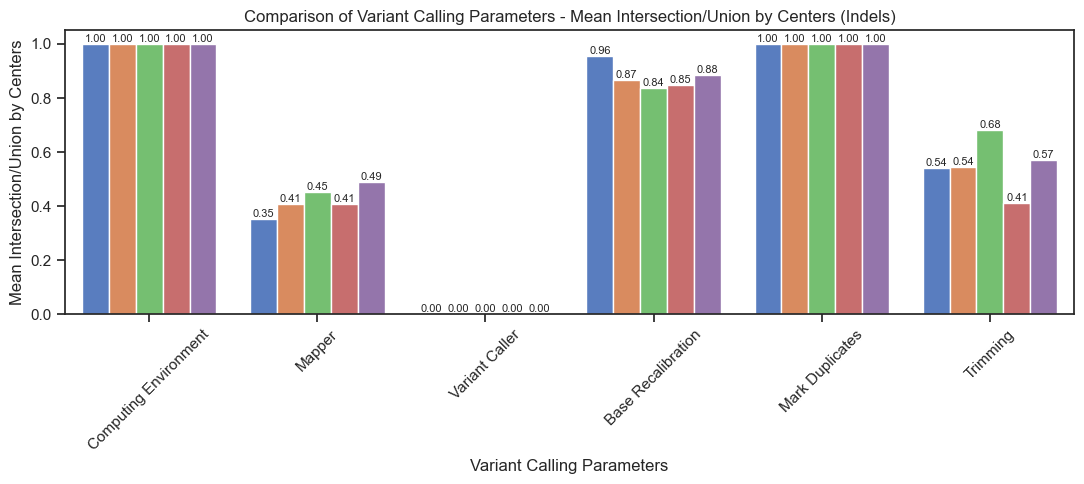

In [280]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a copy of the original DataFrame
df_copy = df_generateds_r_p.copy()

# Splitting the 'TestCase1' and 'TestCase2' columns into separate columns
df_copy[['Mapper1', 'VariantCaller1', 'IsTrimmed1', 'BaseRecalibration1', 'MarkingDuplicates1', 'TestCaseNo1', 'Sample1', 'Environment1']] = df_copy['TestCase1'].str.split('/', expand=True)
df_copy[['Mapper2', 'VariantCaller2', 'IsTrimmed2', 'BaseRecalibration2', 'MarkingDuplicates2', 'TestCaseNo2', 'Sample2', 'Environment2']] = df_copy['TestCase2'].str.split('/', expand=True)

grouped_df = pd.DataFrame() 
filtered_df_environment = df_copy[(df_copy['Mapper1'] == df_copy['Mapper2']) &
                      (df_copy['VariantCaller1'] == df_copy['VariantCaller2']) &
                      (df_copy['BaseRecalibration1'] == df_copy['BaseRecalibration2']) &
                      (df_copy['MarkingDuplicates1'] == df_copy['MarkingDuplicates2']) &
                      (df_copy['Sample1'] == df_copy['Sample2']) &
                      (df_copy['IsTrimmed1'] == df_copy['IsTrimmed2']) &
                      (df_copy['Environment1'] != df_copy['Environment2'])]

grouped_df_e = filtered_df_environment.groupby('Sample1').mean().reset_index()
grouped_df_e['Parameter'] = 'Computing Environment'

filtered_df_mapper = df_copy[(df_copy['Mapper1'] != df_copy['Mapper2']) &
                      (df_copy['VariantCaller1'] == df_copy['VariantCaller2']) &
                      (df_copy['BaseRecalibration1'] == df_copy['BaseRecalibration2']) &
                      (df_copy['MarkingDuplicates1'] == df_copy['MarkingDuplicates2']) &
                      (df_copy['Sample1'] == df_copy['Sample2']) &
                      (df_copy['IsTrimmed1'] == df_copy['IsTrimmed2']) &
                      (df_copy['Environment1'] == df_copy['Environment2'])]

grouped_df_m = filtered_df_mapper.groupby('Sample1').mean().reset_index()
grouped_df_m['Parameter'] = 'Mapper'

filtered_df_variantCaller = df_copy[(df_copy['Mapper1'] == df_copy['Mapper2']) &
                      (df_copy['VariantCaller1'] != df_copy['VariantCaller2']) &
                      (df_copy['BaseRecalibration1'] == df_copy['BaseRecalibration2']) &
                      (df_copy['MarkingDuplicates1'] == df_copy['MarkingDuplicates2']) &
                      (df_copy['Sample1'] == df_copy['Sample2']) &
                      (df_copy['IsTrimmed1'] == df_copy['IsTrimmed2']) &
                      (df_copy['Environment1'] == df_copy['Environment2'])]

grouped_df_vc = filtered_df_variantCaller.groupby('Sample1').mean().reset_index()
grouped_df_vc['Parameter'] = 'Variant Caller'

filtered_df_baseRecalibration = df_copy[(df_copy['Mapper1'] == df_copy['Mapper2']) &
                      (df_copy['VariantCaller1'] == df_copy['VariantCaller2']) &
                      (df_copy['BaseRecalibration1'] != df_copy['BaseRecalibration2']) &
                      (df_copy['MarkingDuplicates1'] == df_copy['MarkingDuplicates2']) &
                      (df_copy['Sample1'] == df_copy['Sample2']) &
                      (df_copy['IsTrimmed1'] == df_copy['IsTrimmed2']) &
                      (df_copy['Environment1'] == df_copy['Environment2'])]

grouped_df_br = filtered_df_baseRecalibration.groupby('Sample1').mean().reset_index()
grouped_df_br['Parameter'] = 'Base Recalibration'

filtered_df_markDuplicates = df_copy[(df_copy['Mapper1'] == df_copy['Mapper2']) &
                      (df_copy['VariantCaller1'] == df_copy['VariantCaller2']) &
                      (df_copy['BaseRecalibration1'] == df_copy['BaseRecalibration2']) &
                      (df_copy['MarkingDuplicates1'] != df_copy['MarkingDuplicates2']) &
                      (df_copy['Sample1'] == df_copy['Sample2']) &
                      (df_copy['IsTrimmed1'] == df_copy['IsTrimmed2']) &
                      (df_copy['Environment1'] == df_copy['Environment2'])]

grouped_df_md = filtered_df_markDuplicates.groupby('Sample1').mean().reset_index()
grouped_df_md['Parameter'] = 'Mark Duplicates'

filtered_df_isTrimmed = df_copy[(df_copy['Mapper1'] == df_copy['Mapper2']) &
                      (df_copy['VariantCaller1'] == df_copy['VariantCaller2']) &
                      (df_copy['BaseRecalibration1'] == df_copy['BaseRecalibration2']) &
                      (df_copy['MarkingDuplicates1'] == df_copy['MarkingDuplicates2']) &
                      (df_copy['Sample1'] == df_copy['Sample2']) &
                      (df_copy['IsTrimmed1'] != df_copy['IsTrimmed2']) &
                      (df_copy['Environment1'] == df_copy['Environment2'])]


grouped_df_it = filtered_df_isTrimmed.groupby('Sample1').mean().reset_index()
grouped_df_it['Parameter'] = 'Trimming'

# Concatenating all the grouped DataFrames
grouped_df = pd.concat([grouped_df_e, grouped_df_m, grouped_df_vc, grouped_df_br, grouped_df_md, grouped_df_it])
grouped_df['Sample1'] = grouped_df['Sample1'].str.upper()

# Plotting the bar plot
sns.set(style="ticks")
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=grouped_df, x='Parameter', y='Inter/Union', hue='Sample1', ci=None, palette=sns.color_palette("muted"))

# Adding data labels to the bars with adjusted vertical alignment
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        label_value = round(height, 4)
        
        # Adjusting vertical alignment based on the bar height
        va = 'bottom' if height >= 0 else 'top'
        offset = 0.003 if height >= 0 else -0.003
        
        ax.annotate(f'{label_value:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, offset), textcoords="offset points",
                    ha='center', va=va, fontsize=8)
plt.legend([],[], frameon=False)

plt.xlabel('Variant Calling Parameters')
plt.ylabel('Mean Intersection/Union by Centers')
plt.title('Comparison of Variant Calling Parameters - Mean Intersection/Union by Centers (Indels)')
#plt.legend(title='Centers', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [269]:
grouped_df_br

,Sample1,Inter/Union,Parameter
0,ea,0.95625,Base Recalibration
1,fd,0.86750,Base Recalibration
2,il,0.83875,Base Recalibration
3,ll,0.84875,Base Recalibration
4,nc,0.88375,Base Recalibration
